In [213]:
import pandas as pd
import numpy as np
from functools import reduce
import matplotlib.pyplot as plt

IMPORT_OR_EXPORT = "GVA"

if IMPORT_OR_EXPORT == "IMPORT":
    IMGR_OR_EXGR = "IMGR"
elif IMPORT_OR_EXPORT == "EXPORT":
    IMGR_OR_EXGR = "EXGR"
elif IMPORT_OR_EXPORT == "GVA":
    IMGR_OR_EXGR = "GVA"
else:
    print("INVALID!") 

START_YEAR = 2014
END_YEAR   = 2020

In [ ]:
# Pre-processing AAMNE : 2014 - 2020

aamne_df = pd.read_csv("./input/AAMNE.csv")
aamne_df = aamne_df[aamne_df["year"].isin(range(START_YEAR,END_YEAR+1))]

#aamne_df = aamne_df[aamne_df["cou"].isin(eps_df["REF_AREA"].unique())]

aamne_df = aamne_df.pivot_table(index=["cou", "year"],
                                  columns=["isic", "own"],
                                  values=IMGR_OR_EXGR,
                                  aggfunc="first")

aamne_df.columns = [f"{industry}_{'Domestic' if own == 'D_MNE' else 'Domestic_OTH' if own == 'D_OTH' else 'Foreign'}"
                    for industry, own in aamne_df.columns]

aamne_df = aamne_df.reset_index().rename(columns={"cou": "REF_AREA", "year": "TIME_PERIOD"})

for column_name in aamne_df.columns:
    if column_name.endswith("OTH"):
        aamne_df = aamne_df.drop(column_name, axis=1)

aamne_df["TIME_PERIOD"] = aamne_df["TIME_PERIOD"].astype(int)

aamne_df.to_excel(f"./output/AAMNE_{IMPORT_OR_EXPORT}.xlsx")

COUNTRY_SET = aamne_df["REF_AREA"].unique()



81

In [215]:
# Pre-processing EPS : 2014 - 2020 (CHECK FOR UP-TO-DATE)

eps_df = pd.read_csv("./input/EPS.csv")
eps_df = eps_df[eps_df["TIME_PERIOD"].isin(range(START_YEAR,END_YEAR+1))]
eps_df = eps_df[eps_df["CLIM_POL"]=="EPS"]
eps_df = eps_df[["REF_AREA", "TIME_PERIOD", "OBS_VALUE"]]

eps_df["TIME_PERIOD"] = eps_df["TIME_PERIOD"].astype(int)
eps_df = eps_df[eps_df["REF_AREA"].isin(COUNTRY_SET)]
eps_df = eps_df.rename(columns={"OBS_VALUE": "EPS"})

eps_df.to_excel("./output/EPS.xlsx")

eps_df["TIME_PERIOD"].unique()

array([2014, 2015, 2016, 2017, 2018, 2019, 2020])

In [ ]:
# Pre-processing EPI : 2014 - 2020 (FIXED)

INDICATORS = ["BCA", "CDA", "CHA",
              "FGA", "GHO", "GTI",
              "GTP", "LUF", "NDA"]

INDICATOR_WEIGHTS = {"BCA": 0.03, "CDA": 0.33, "CHA": 0.08,
                     "FGA": 0.06, "GHO": 0.05, "GTI": 0.2,
                     "GTP": 0.20, "LUF": 0.02, "NDA": 0.03}

FILEPATHS = [f"./input/EPI/{indicator}_ind_na.csv" for indicator in INDICATORS]

epi_df = pd.DataFrame()

for idx, path in enumerate(FILEPATHS):
    indicator_name = INDICATORS[idx]
    df = pd.read_csv(path)
    df = df.melt(id_vars="iso",
                 value_vars=[f"{indicator_name}.ind.{year}" for year in range(START_YEAR, END_YEAR+1)],
                 var_name="TIME_PERIOD",
                 value_name=f"{indicator_name}_VALUE").rename(columns={"iso": "REF_AREA"})
    if idx == 0:
        epi_df = df
    else:
        epi_df = pd.concat([epi_df, df], axis=1)

epi_df:pd.DataFrame = epi_df.loc[:,~epi_df.columns.duplicated()].copy() # MAGIC
epi_df["EPI"] = 0 

#epi_df.fillna(0.0, inplace=True)
epi_df = epi_df.dropna()

for indicator_name, weight in INDICATOR_WEIGHTS.items():
    epi_df["EPI"] += epi_df[f"{indicator_name}_VALUE"] * weight
    epi_df = epi_df.drop(f"{indicator_name}_VALUE", axis=1)

epi_df["TIME_PERIOD"] = epi_df["TIME_PERIOD"].str.split(".").str[-1].astype(int)
epi_df = epi_df[epi_df["REF_AREA"].isin(COUNTRY_SET)]

epi_df.to_excel("./output/EPI.xlsx")
epi_df.to_csv("./output/EPI.csv")

72

    REF_AREA     GROUP
4        AGO  Non-OECD
7        ARG  Non-OECD
15       BGD  Non-OECD
29       BGR  Non-OECD
17       BLR  Non-OECD
..       ...       ...
176      SVK      OECD
177      SVN      OECD
189      SWE      OECD
201      TUR      OECD
209      USA      OECD

[72 rows x 2 columns]


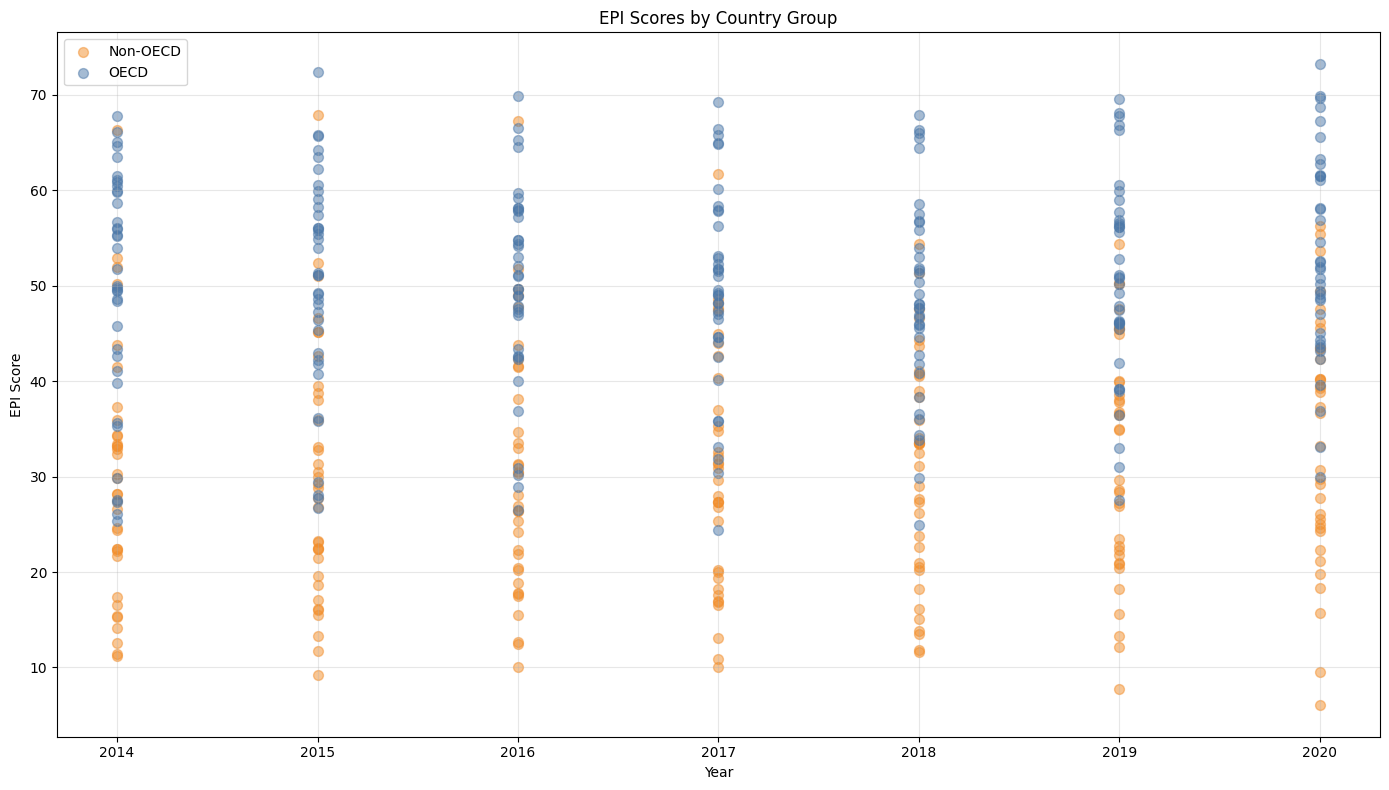

In [ ]:
#plotting EPI scores for OECD and non-OECD nountries

oecd_codes = [
    "AUS", "AUT", "BEL", "CAN", "CHL", "COL", "CRI", "CZE",
    "DNK", "EST", "FIN", "FRA", "DEU", "GRC", "HUN", "ISL",
    "IRL", "ISR", "ITA", "JPN", "LVA", "LTU", "LUX", "MEX",
    "NLD", "NZL", "NOR", "POL", "PRT", "SVK", "SVN", "KOR",
    "ESP", "SWE", "CHE", "TUR", "GBR", "USA"
]

oecd_eu_codes = [
    "AUT", "BEL", "CZE", "DNK", "EST", "FIN", "FRA", "DEU",
    "GRC", "HUN", "IRL", "ITA", "LVA", "LTU", "LUX", "NLD",
    "POL", "PRT", "SVK", "SVN", "ESP", "GBR", "SWE"
]

epi_df["GROUP"] = np.select(
    [
        #epi_df["REF_AREA"].isin(oecd_eu_codes),
        epi_df["REF_AREA"].isin(oecd_codes)
    ],
    [
        #"EU in OECD",
        "OECD"
    ],
    default="Non-OECD"
)

print(
    epi_df[["REF_AREA", "GROUP"]]
    .drop_duplicates()
    .sort_values(["GROUP", "REF_AREA"])
)

colors = {
    "OECD": "#4C78A8",          # blue
    #"EU in OECD": "#1F4E79",    # darker blue
    "Non-OECD": "#F28E2B"       # orange
}

markers = {
    "OECD": "o",
    #"EU in OECD": "x",
    "Non-OECD": "o"
}

plt.figure(figsize=(14, 8))

for group, group_df in epi_df.groupby("GROUP"):
    plt.scatter(
        group_df["TIME_PERIOD"],
        group_df["EPI"],
        label=group,
        color=colors[group],
        marker=markers[group],
        alpha=0.5,
        s=50
    )

plt.xticks(range(2014, 2020 + 1))
plt.xlabel("Year")
plt.ylabel("EPI Score")
plt.title("EPI Scores by Country Group")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [218]:
# # Pre-processing CCPI : 2020 - 2022


# ccpi_df = pd.read_csv("./input/CCPI.csv")

# ccpi_df = ccpi_df.melt(id_vars="ISO",
#                        value_vars=[str(year) for year in range(START_YEAR, END_YEAR+1)],
#                        var_name="TIME_PERIOD",
#                        value_name="CCPI_SCORE").rename(columns={"ISO": "REF_AREA"})

# ccpi_df["TIME_PERIOD"] = ccpi_df["TIME_PERIOD"].astype(int)
# ccpi_df = ccpi_df[ccpi_df["REF_AREA"].isin(COUNTRY_SET)]

# ccpi_df.to_excel("./output/CCPI.xlsx")

# ccpi_df["TIME_PERIOD"].unique()

In [219]:
# Pre-processing GDP : 1960 - 2025

gdp_df=pd.read_csv("./input/GDP_DATA.csv")

gdp_df = gdp_df.melt("Country Code",
                      [str(year) for year in range(START_YEAR, END_YEAR+1)],
                    "TIME_PERIOD",
                    "GDP").rename(columns = {"Country Code": "REF_AREA"})

gdp_df["TIME_PERIOD"] = gdp_df["TIME_PERIOD"].astype(int)
gdp_df = gdp_df[gdp_df["REF_AREA"].isin(COUNTRY_SET)]

gdp_df.to_excel("./output/GDP.xlsx")

gdp_df["TIME_PERIOD"].unique()

array([2014, 2015, 2016, 2017, 2018, 2019, 2020])

In [233]:
# Pre-processing TRADE : 1960 - 2025

trade_df = pd.read_csv("./input/TRADE_OPEN.csv")
trade_df = trade_df.melt("Country Code",
                      [str(year) for year in range(START_YEAR, END_YEAR+1)],
                    "TIME_PERIOD",
                    "TRADE").rename(columns = {"Country Code": "REF_AREA"})

trade_df["TIME_PERIOD"] = trade_df["TIME_PERIOD"].astype(int)
trade_df = trade_df[trade_df["REF_AREA"].isin(COUNTRY_SET)]

trade_df.to_excel("./output/TRADE.xlsx")

trade_df["TIME_PERIOD"].unique()
len(trade_df["REF_AREA"].unique())

79

In [221]:
# # Pre-processing INTEREST PAYMENTS : 1960 - 2025
# START_YEAR = 2014
# END_YEAR   = 2020
# interest_df = pd.read_csv("./input/INTEREST_PAYMENTS.csv")

# interest_df = interest_df.melt(id_vars="Country Code",
#                        value_vars=[str(year) for year in range(START_YEAR, END_YEAR+1)],
#                        var_name="TIME_PERIOD",
#                        value_name="INTEREST_PAYMENTS").rename(columns={"Country Code": "REF_AREA"})

# interest_df["TIME_PERIOD"] = interest_df["TIME_PERIOD"].astype(int)
# interest_df = interest_df[interest_df["REF_AREA"].isin(COUNTRY_SET)]

# interest_df.to_excel("./output/INTEREST_PAYMENTS.xlsx")

# interest_df["TIME_PERIOD"].unique()

In [222]:
# Pre-processing OIL RENTS : 1960 - 2025

oil_rents_df = pd.read_csv("./input/OIL_RENTS.csv")

oil_rents_df = oil_rents_df.melt(id_vars="Country Code",
                       value_vars=[str(year) for year in range(START_YEAR, END_YEAR+1)],
                       var_name="TIME_PERIOD",
                       value_name="OIL_RENTS").rename(columns={"Country Code": "REF_AREA"})

oil_rents_df["TIME_PERIOD"] = oil_rents_df["TIME_PERIOD"].astype(int)
oil_rents_df = oil_rents_df[oil_rents_df["REF_AREA"].isin(COUNTRY_SET)]

oil_rents_df.to_excel("./output/OIL_RENTS.xlsx")

oil_rents_df["TIME_PERIOD"].unique()

array([2014, 2015, 2016, 2017, 2018, 2019, 2020])

In [223]:
# Pre-processing FINANCIAL DEVELOPMENT : 1980 - 2020

financial_dev_df = pd.read_csv("./input/FINANCIAL_DEVELOPMENT.csv")
financial_dev_df = financial_dev_df[financial_dev_df["INDICATOR"]=="Financial Development Index"]

financial_dev_df["COUNTRY_CODE"] = financial_dev_df["SERIES_CODE"].str[0:3]
financial_dev_df = financial_dev_df[financial_dev_df["COUNTRY_CODE"].isin(aamne_df["REF_AREA"].unique())]

financial_dev_df = financial_dev_df.melt(id_vars="COUNTRY_CODE",
                       value_vars=[str(year) for year in range(START_YEAR, END_YEAR+1)],
                       var_name="TIME_PERIOD",
                       value_name="FINANCIAL_DEVELOPMENT").rename(columns={"COUNTRY_CODE": "REF_AREA"})

financial_dev_df["TIME_PERIOD"] = financial_dev_df["TIME_PERIOD"].astype(int)
financial_dev_df = financial_dev_df[financial_dev_df["REF_AREA"].isin(COUNTRY_SET)]

financial_dev_df.to_excel("./output/FINANCIAL_DEVELOPMENT.xlsx")

financial_dev_df["TIME_PERIOD"].unique()

array([2014, 2015, 2016, 2017, 2018, 2019, 2020])

In [242]:
# 2. Fill missing keys with placeholders
fill_values = {'REF_AREA': 'UNKNOWN_AREA', 'TIME_PERIOD': 'UNKNOWN_TIME'}
filled_dfs = [df.fillna(fill_values) for df in [eps_df, epi_df, aamne_df, gdp_df, trade_df, oil_rents_df, financial_dev_df]]

# 3. Merge using how='outer' to ensure no rows or unique columns are dropped
final_df = reduce(
    lambda left, right: pd.merge(left, right, on=['REF_AREA', 'TIME_PERIOD'], how='outer'), 
    filled_dfs
)

# 4. Revert placeholders back to NaN
final_df[['REF_AREA', 'TIME_PERIOD']] = final_df[['REF_AREA', 'TIME_PERIOD']].replace({
    'UNKNOWN_AREA': np.nan, 
    'UNKNOWN_TIME': np.nan
})

final_df = final_df.dropna(subset=["EPI"])

final_df.to_excel(f"./output/COMPLETE_{IMPORT_OR_EXPORT}.xlsx")
final_df.to_csv(f"./output/COMPLETE_{IMPORT_OR_EXPORT}.csv")
len(final_df["REF_AREA"].unique())

72

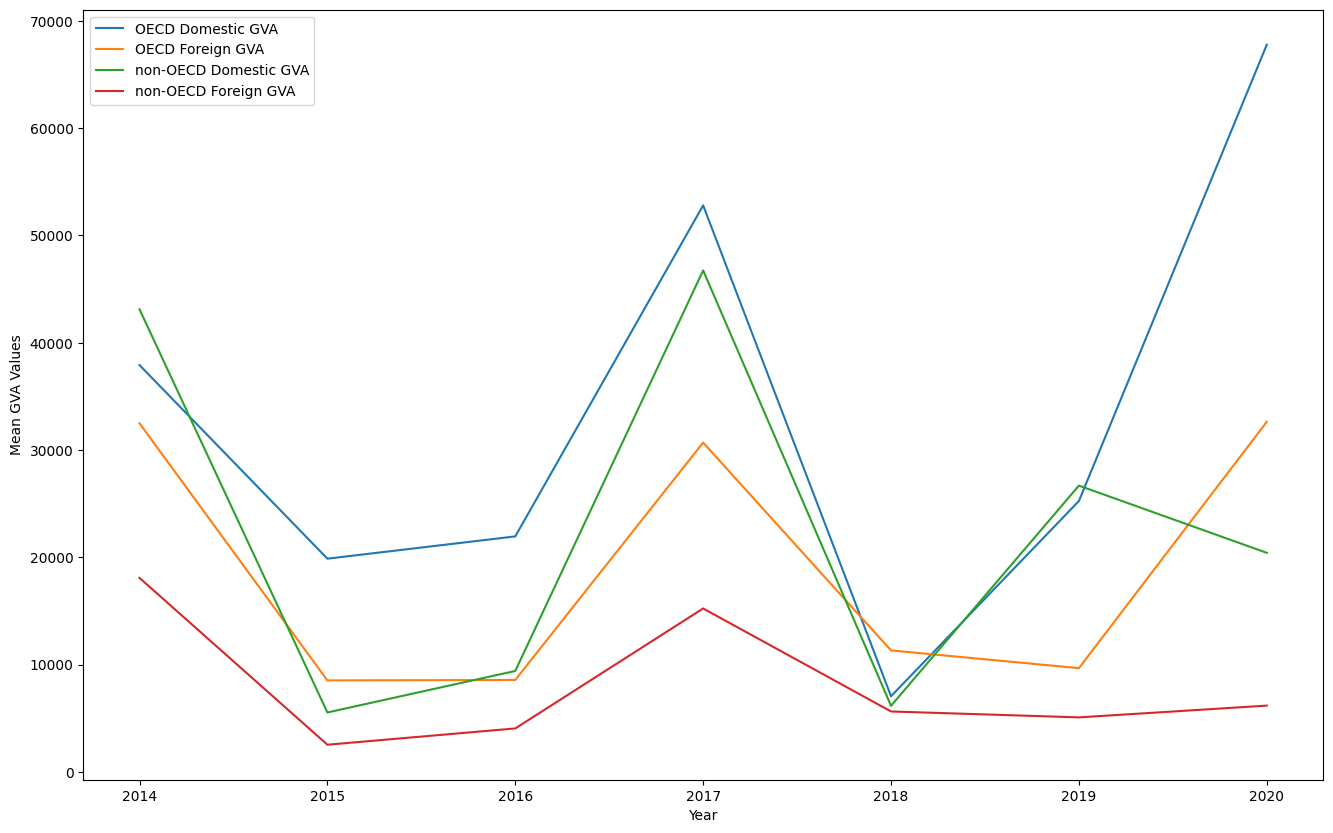

In [255]:
df=pd.read_csv("output/COMPLETE_GVA.csv")
df.drop("Unnamed: 0", axis=1, inplace=True)

EMISSION_INTENSIVE_INDUSTRIES=["B05T09","C17T18","C19","C20","C23","C24","D35_E36T39"]

oecd_df=df[df["REF_AREA"].isin(oecd_codes)]
non_oecd_df=df[df["REF_AREA"].isin(set(df["REF_AREA"].unique()).difference(set(oecd_df["REF_AREA"].unique())))]

def plot():
    oecd_domestic_result=[]
    non_oecd_domestic_result=[]
    oecd_foreign_result=[]
    non_oecd_foreign_result=[]

    for industry in EMISSION_INTENSIVE_INDUSTRIES:
        data=oecd_df.groupby("TIME_PERIOD")[f"{industry}_Domestic"].agg(["mean"]).reset_index()
        oecd_domestic_result.append(data["mean"])

        data=oecd_df.groupby("TIME_PERIOD")[f"{industry}_Foreign"].agg(["mean"]).reset_index()
        oecd_foreign_result.append(data["mean"])

        data=non_oecd_df.groupby("TIME_PERIOD")[f"{industry}_Domestic"].agg(["mean"]).reset_index()
        non_oecd_domestic_result.append(data["mean"])
        
        data=non_oecd_df.groupby("TIME_PERIOD")[f"{industry}_Foreign"].agg(["mean"]).reset_index()
        non_oecd_foreign_result.append(data["mean"])

    oecd_dom_data=np.sum(oecd_domestic_result, axis=1)
    oecd_for_data=np.sum(oecd_foreign_result, axis=1)
    non_oecd_dom_data=np.sum(non_oecd_domestic_result, axis=1)
    non_oecd_for_data=np.sum(non_oecd_foreign_result, axis=1)

    plt.plot(np.arange(START_YEAR,END_YEAR+1),oecd_dom_data,label="OECD Domestic GVA")
    plt.plot(np.arange(START_YEAR,END_YEAR+1),oecd_for_data,label="OECD Foreign GVA")
    plt.plot(np.arange(START_YEAR,END_YEAR+1),non_oecd_dom_data,label="non-OECD Domestic GVA")
    plt.plot(np.arange(START_YEAR,END_YEAR+1),non_oecd_for_data,label="non-OECD Foreign GVA")

plt.figure(figsize=(16,10))
plt.xlabel("Year")
plt.ylabel("Mean GVA Values")

plot()

plt.legend()
plt.show()